In [3]:
# ============================================
# SigMon-LHC — Signal Analysis Notebook
# CERN LHC Magnet Circuit Analysis
# ============================================

import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from src.simulator import generate_signal
from src.analyzer import analyze_circuit, detect_anomalies

print("✅ All imports successful")

✅ All imports successful


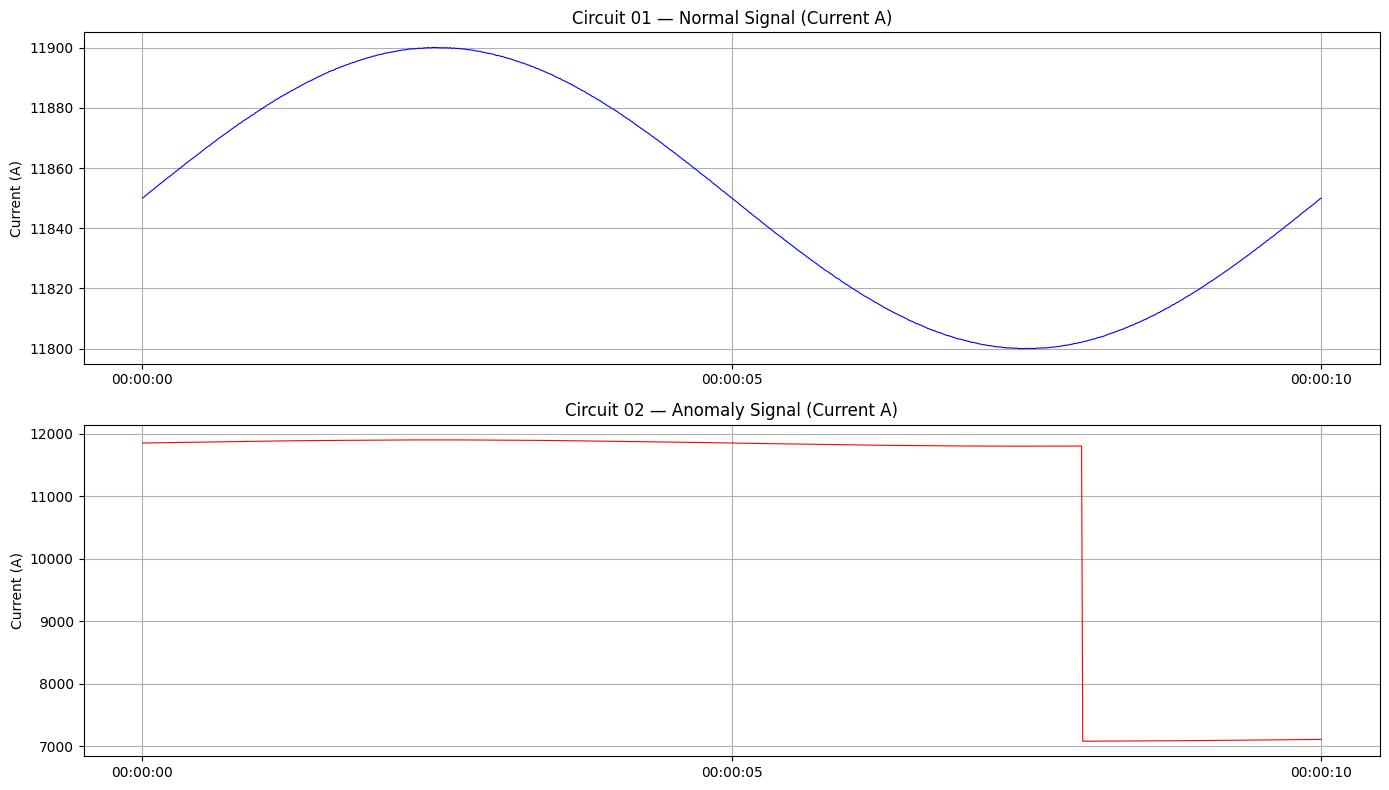

✅ Signals plotted


In [5]:
# ============================================
# Generate signals for 3 circuits
# ============================================

df_normal = generate_signal("circuit_01", n_samples=1000, anomaly=False)
df_anomaly = generate_signal("circuit_02", n_samples=1000, anomaly=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Normal signal
axes[0].plot(df_normal["timestamp"], df_normal["current_A"], color="blue", linewidth=0.8)
axes[0].set_title("Circuit 01 — Normal Signal (Current A)")
axes[0].set_ylabel("Current (A)")
axes[0].grid(True)

# Anomaly signal
axes[1].plot(df_anomaly["timestamp"], df_anomaly["current_A"], color="red", linewidth=0.8)
axes[1].set_title("Circuit 02 — Anomaly Signal (Current A)")
axes[1].set_ylabel("Current (A)")
axes[1].grid(True)

plt.tight_layout()
plt.show()
print("✅ Signals plotted")

In [9]:
# ============================================
# Analysis Summary + Alert System
# ============================================

def raise_alert(circuit_id: str, result: dict):
    if result["status"] == "CRITICAL":
        print(f"🚨 CRITICAL ALERT — {circuit_id} | anomaly_rate={result['anomaly_rate']} | temp_max={result['temperature_max']:.3f}K")
    elif result["status"] == "WARNING":
        print(f"⚠️  WARNING ALERT — {circuit_id} | anomaly_rate={result['anomaly_rate']} | temp_max={result['temperature_max']:.3f}K")
    else:
        print(f"✅ OK             — {circuit_id} | anomaly_rate={result['anomaly_rate']} | temp_max={result['temperature_max']:.3f}K")


# Circuit 06 — severe anomaly (CRITICAL)
df_06 = generate_signal("circuit_06", n_samples=1000, anomaly=True, noise_level=0)
df_06["temperature_K"] = df_06["temperature_K"] + 1.0
result_06 = analyze_circuit(df_06)

# Circuit 07 — moderate anomaly (WARNING)
df_07 = generate_signal("circuit_07", n_samples=1000, anomaly=True, noise_level=0.02)
df_07["temperature_K"] = df_07["temperature_K"] + 0.4
result_07 = analyze_circuit(df_07)

circuits = {
    "circuit_01": analyze_circuit(generate_signal("circuit_01", n_samples=1000)),
    "circuit_02": analyze_circuit(generate_signal("circuit_02", n_samples=1000)),
    "circuit_03": analyze_circuit(generate_signal("circuit_03", n_samples=1000, anomaly=True)),
    "circuit_04": analyze_circuit(generate_signal("circuit_04", n_samples=1000)),
    "circuit_05": analyze_circuit(generate_signal("circuit_05", n_samples=1000, anomaly=True)),
    "circuit_06": result_06,
    "circuit_07": result_07,
}

# Summary table
summary_df = pd.DataFrame(circuits.values())
summary_df = summary_df[["circuit_id", "current_mean", "current_std",
                          "temperature_max", "n_anomalies", "anomaly_rate", "status"]]
print(summary_df.to_string(index=False))

# Alert dashboard
print("\n" + "=" * 60)
print("  SIGMON-LHC — CIRCUIT ALERT DASHBOARD")
print("=" * 60)
for cid, result in circuits.items():
    raise_alert(cid, result)
print("=" * 60)

circuit_id  current_mean  current_std  temperature_max  n_anomalies  anomaly_rate   status
circuit_01  11849.999475    35.354670         1.924063            0         0.000       OK
circuit_02  11849.999851    35.354296         1.923340            0         0.000       OK
circuit_03  11840.520765   214.807407         2.406953            2         0.002       OK
circuit_04  11850.000373    35.356215         1.924031            0         0.000       OK
circuit_05  10767.297577  2004.279156         2.424530            0         0.000       OK
circuit_06  11130.857592  1709.104624         3.404572         1000         1.000 CRITICAL
circuit_07  11277.329964  1551.330657         2.806633          121         0.121 CRITICAL

  SIGMON-LHC — CIRCUIT ALERT DASHBOARD
✅ OK             — circuit_01 | anomaly_rate=0.0 | temp_max=1.924K
✅ OK             — circuit_02 | anomaly_rate=0.0 | temp_max=1.923K
✅ OK             — circuit_03 | anomaly_rate=0.002 | temp_max=2.407K
✅ OK             — circuit_04